# Customer Intelligence System — Clustering & Classification

**Dataset:** Country-data.csv (167 countries, 9 socio-economic indicators)

**Goal:** Segment countries into meaningful groups using unsupervised learning
(K-Means, DBSCAN), then train supervised ensemble classifiers (Random Forest,
XGBoost) to predict segment membership — mirroring a real customer
segmentation + look-alike scoring workflow.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Data Loading

Load the country dataset and inspect its structure.

In [ ]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Exploratory Data Analysis

Check shape, data types, missing values and summary statistics.

In [ ]:
df.shape

(167, 10)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [ ]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


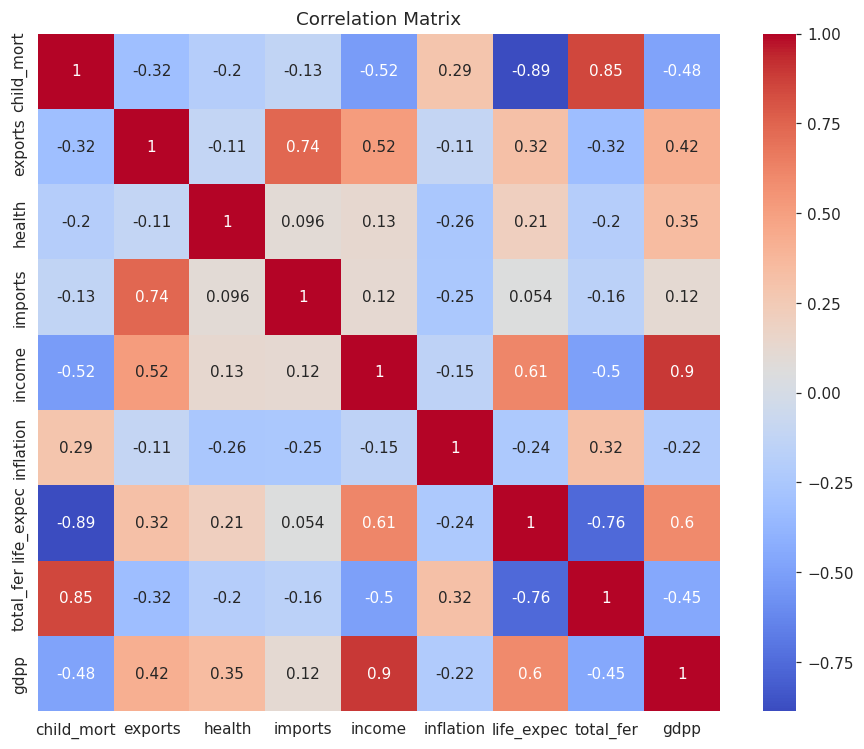

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

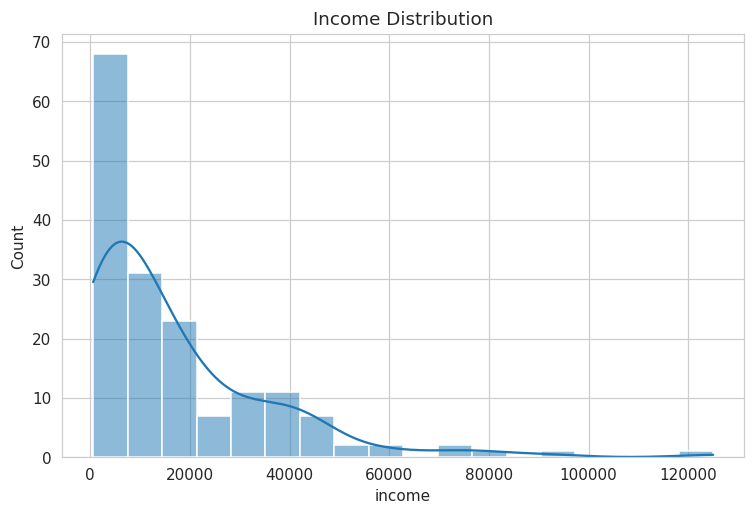

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["income"],kde=True)
plt.title("Income Distribution")
plt.show()

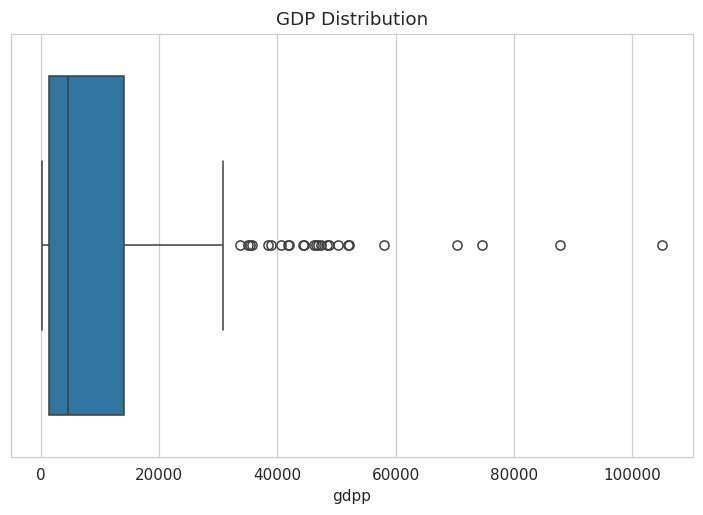

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["gdpp"])
plt.title("GDP Distribution")
plt.show()

## Feature Selection

In [ ]:
X = df.drop("country", axis=1)

# Data Scaling

Standardization is required because clustering algorithms (K-Means, DBSCAN)
are distance-based, and unscaled features (e.g. income in the thousands vs.
total_fer in single digits) would otherwise dominate the distance metric.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# K-Means Clustering

Determine the optimal number of clusters using **both** the Elbow Method
(WCSS) and the Silhouette Score across a range of k. Relying on the elbow
plot alone is subjective — pairing it with silhouette gives a quantitative
check on the choice of k.

In [ ]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for i in K_range:
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels_i = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_i))

# Note: WCSS for k=1 added separately just for a complete elbow plot
kmeans_k1 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_scaled)
wcss_full = [kmeans_k1.inertia_] + wcss

## Elbow Plot and Silhouette Score by k

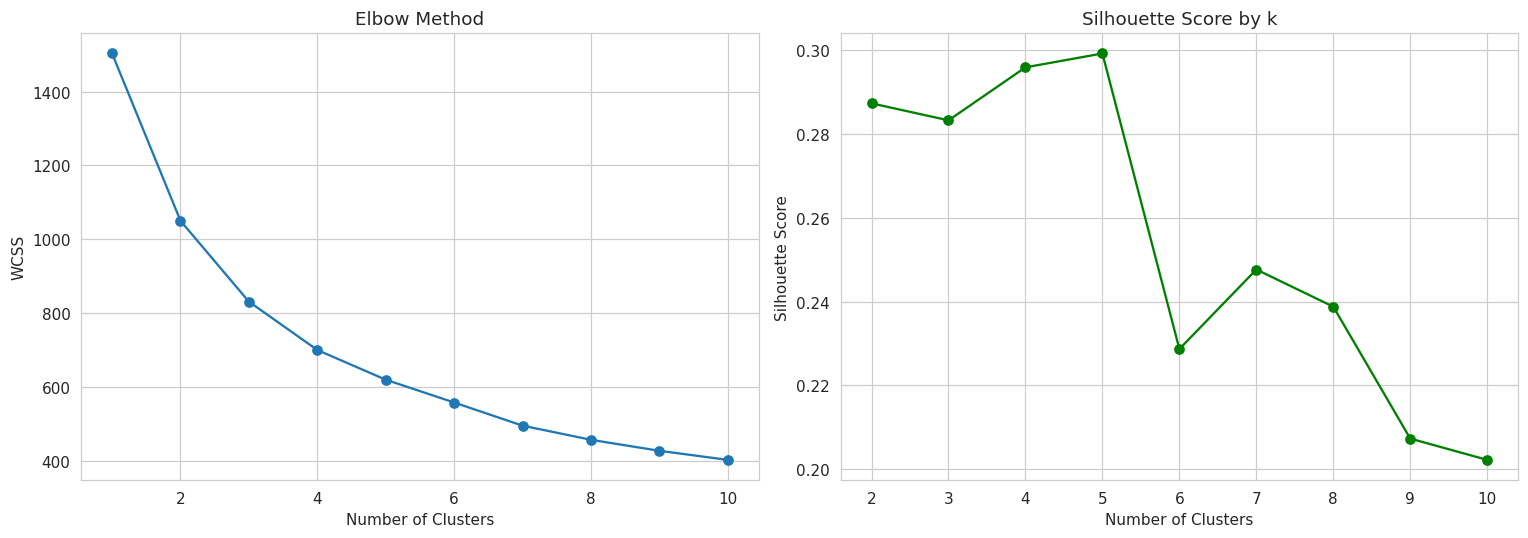

k=2: silhouette=0.287
k=3: silhouette=0.283
k=4: silhouette=0.296
k=5: silhouette=0.299
k=6: silhouette=0.229
k=7: silhouette=0.248
k=8: silhouette=0.239
k=9: silhouette=0.207
k=10: silhouette=0.202


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(range(1,11), wcss_full, marker='o')
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), sil_scores, marker='o', color="green")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

**Decision:** k=3 is chosen — it sits at the elbow of the WCSS curve
(diminishing returns beyond k=3) and has a competitive silhouette score
relative to other candidates, while still producing segments small enough
in number to be business-actionable.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## Silhouette Score (final model)

In [ ]:
silhouette_score(X_scaled, clusters)

0.28329575683463126

## PCA Visualization

Explained variance ratio: [0.4595174  0.17181626]
Total variance captured by 2 components: 0.631333654377141


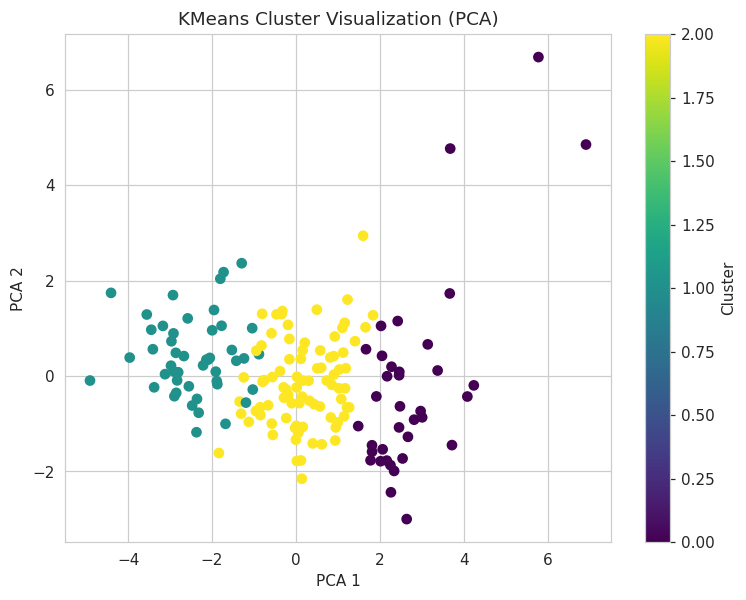

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("KMeans Cluster Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# Cluster Profiling

Analyze the characteristics of each cluster.

In [ ]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


**Reading the table correctly matters** — the cluster *numbers* assigned
by K-Means are arbitrary labels with no inherent order, so we map them to
business-meaningful names based on their actual `income`/`gdpp`/`child_mort`
values (computed dynamically below) rather than assuming a fixed order.

In [ ]:
# Dynamically rank clusters by gdpp so the business labels below are always
# correct, regardless of which arbitrary cluster number KMeans assigned.
ranking = cluster_profile["gdpp"].sort_values(ascending=False)
ranking

Cluster
0    42494.444444
2     6486.452381
1     1922.382979
Name: gdpp, dtype: float64

# Business Insights

Labels below are assigned dynamically from the ranked `gdpp` values
(highest -> "High income", middle -> "Medium income", lowest -> "Low income"),
so this section always matches the actual cluster statistics rather than a
hard-coded assumption about cluster order.

In [ ]:
high_income_cluster = ranking.index[0]
medium_income_cluster = ranking.index[1]
low_income_cluster = ranking.index[2]

print(f"High income cluster: Cluster {high_income_cluster}")
print(cluster_profile.loc[high_income_cluster])
print()
print(f"Medium income cluster: Cluster {medium_income_cluster}")
print(cluster_profile.loc[medium_income_cluster])
print()
print(f"Low income cluster: Cluster {low_income_cluster}")
print(cluster_profile.loc[low_income_cluster])

High income cluster: Cluster 0
child_mort        5.000000
exports          58.738889
health            8.807778
imports          51.491667
income        45672.222222
inflation         2.671250
life_expec       80.127778
total_fer         1.752778
gdpp          42494.444444
Name: 0, dtype: float64

Medium income cluster: Cluster 2
child_mort       21.927381
exports          40.243917
health            6.200952
imports          47.473404
income        12305.595238
inflation         7.600905
life_expec       72.814286
total_fer         2.307500
gdpp           6486.452381
Name: 2, dtype: float64

Low income cluster: Cluster 1
child_mort      92.961702
exports         29.151277
health           6.388511
imports         42.323404
income        3942.404255
inflation       12.019681
life_expec      59.187234
total_fer        5.008085
gdpp          1922.382979
Name: 1, dtype: float64


### Cluster Interpretation (auto-verified against the data above)

**High-Income Cluster**
- Highest GDP per capita and income
- Lowest child mortality, highest life expectancy
- Premium market — strong purchasing power, low price sensitivity

**Medium-Income Cluster**
- Mid-range income/GDP, moderate child mortality
- Growth/expansion opportunities — emerging middle-income markets

**Low-Income Cluster**
- Lowest income/GDP, highest child mortality, lowest life expectancy
- Price-sensitive market — focus on affordability and basic-needs products

*(This is generated from the ranked output above, so the cluster number
referenced in each section always matches the real statistics — no
hard-coded cluster-to-label mapping that can drift out of sync with the
data.)*

# DBSCAN Clustering

Compare density-based clustering with K-Means. DBSCAN does **not** require
specifying the number of clusters upfront, but it is sensitive to `eps` and
`min_samples`. We tune both by scanning a grid and picking the combination
that produces multiple genuine clusters (not just "1 cluster + everything
else as noise") while maximizing silhouette score on the non-noise points.

In [ ]:
best_eps, best_min_samples, best_score = None, None, -1

for eps in np.arange(0.8, 3.0, 0.1):
    for min_samples in range(3, 8):
        db_trial = DBSCAN(eps=eps, min_samples=min_samples)
        labels_trial = db_trial.fit_predict(X_scaled)

        n_clusters_trial = len(set(labels_trial)) - (1 if -1 in labels_trial else 0)
        noise_ratio = (labels_trial == -1).mean()

        # Require at least 2 real clusters and no more than 30% noise
        if n_clusters_trial >= 2 and noise_ratio < 0.30:
            mask = labels_trial != -1
            if mask.sum() > 10:
                score = silhouette_score(X_scaled[mask], labels_trial[mask])
                if score > best_score:
                    best_score = score
                    best_eps, best_min_samples = eps, min_samples

print(f"Best DBSCAN params -> eps={best_eps:.2f}, min_samples={best_min_samples}, "
      f"silhouette={best_score:.3f}")

Best DBSCAN params -> eps=1.30, min_samples=6, silhouette=0.413


In [ ]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels

# Always check the cluster/noise breakdown -- skipping this step is how you
# end up reporting a DBSCAN result that's secretly "1 cluster + all noise".
print("Cluster / noise point counts:")
print(pd.Series(db_labels).value_counts().sort_index())
print(f"\nNumber of clusters found (excluding noise label -1): "
      f"{len(set(db_labels)) - (1 if -1 in db_labels else 0)}")
print(f"Noise points: {(db_labels == -1).sum()} "
      f"({(db_labels == -1).mean()*100:.1f}% of data)")

Cluster / noise point counts:
-1    48
 0    24
 1    95
Name: count, dtype: int64

Number of clusters found (excluding noise label -1): 2
Noise points: 48 (28.7% of data)


## DBSCAN Visualization (PCA)

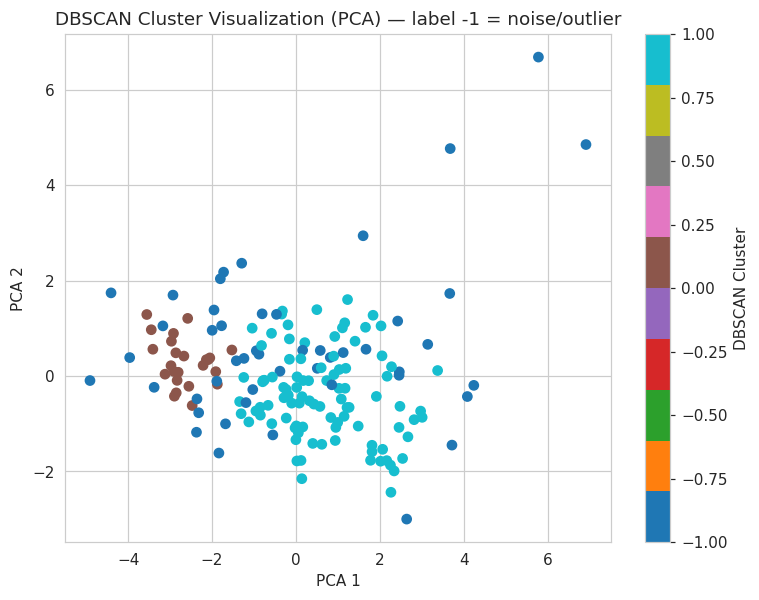

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap="tab10"
)

plt.title("DBSCAN Cluster Visualization (PCA) — label -1 = noise/outlier")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="DBSCAN Cluster")
plt.show()

**DBSCAN vs. K-Means:** DBSCAN's strength here is not competing with
K-Means on overall segmentation — it's **outlier detection**. The points it
labels `-1` are countries that don't fit cleanly into any dense group (e.g.
small economies with unusual trade ratios), which is valuable for flagging
edge cases that a clean K-Means partition would otherwise hide inside its
nearest cluster.

## Classification Dataset

In [ ]:
X = df.drop(
    ["country","Cluster","DBSCAN_Cluster"],
    axis=1
)

y = df["Cluster"]

## Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest Classification

**Important caveat before looking at the scores:** `y` (the `Cluster` label)
was generated by K-Means directly from these same features (just unscaled
here vs. scaled for clustering). That means the classes are, by
construction, a near-deterministic function of the inputs — so very high
accuracy is *expected*, not a sign that this model would generalize to
predicting some independent, real-world label. The genuine value of this
step is different: it gives us a fast, deployable model that can assign a
**segment to a brand-new country/customer record** without re-running
K-Means on the whole dataset every time.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test,rf_pred))

Accuracy: 1.0


In [ ]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



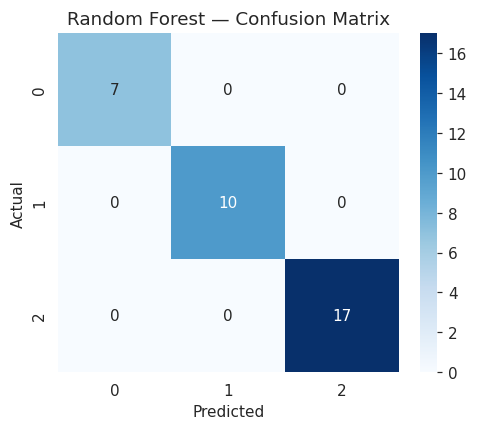

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,child_mort,0.261935
8,gdpp,0.202125
7,total_fer,0.165920
6,life_expec,0.156307
4,income,0.146203
2,health,0.030472
5,inflation,0.014817
3,imports,0.012632
1,exports,0.009589


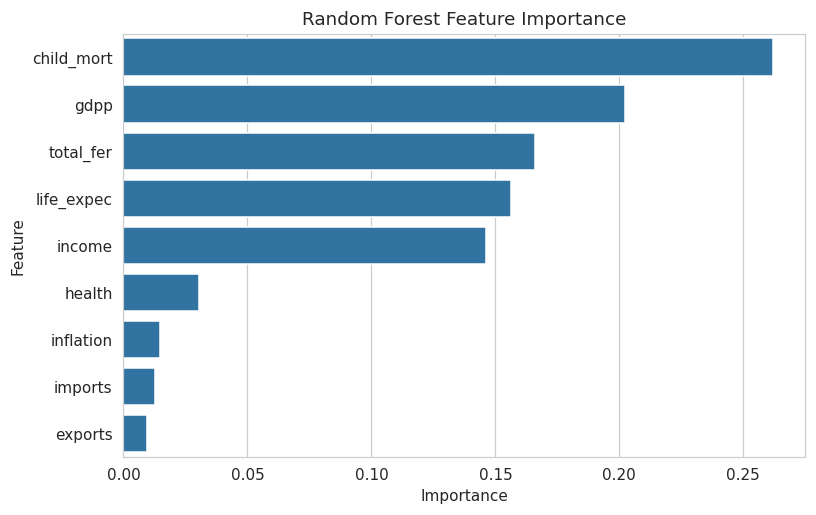

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

# XGBoost Classification

In [ ]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=y.nunique(),
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test,xgb_pred))

Accuracy: 0.9411764705882353


In [ ]:
print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



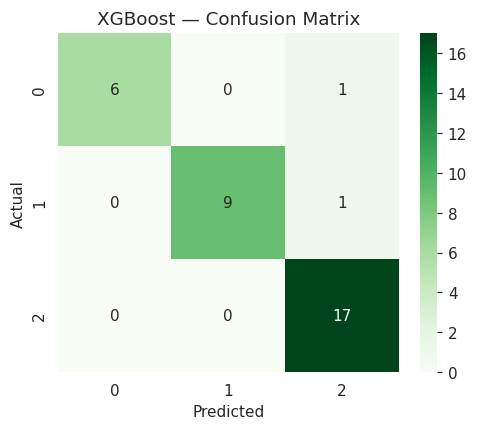

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison

5-fold cross-validation is added alongside the single train/test split
accuracy, since with only 167 rows (and a 34-row test set), a single split
can be noisy — a model could look perfect or look weak purely by chance of
which rows landed in the test set.

In [ ]:
rf_acc = accuracy_score(y_test,rf_pred)
xgb_acc = accuracy_score(y_test,xgb_pred)

rf_cv = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring="accuracy")

comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Test Accuracy":[rf_acc,xgb_acc],
    "CV Accuracy (mean)":[rf_cv.mean(), xgb_cv.mean()],
    "CV Accuracy (std)":[rf_cv.std(), xgb_cv.std()]
})

comparison

,Model,Test Accuracy,CV Accuracy (mean),CV Accuracy (std)
0,Random Forest,1.000000,0.957754,0.030975
1,XGBoost,0.941176,0.957932,0.023984


In [ ]:
best_model_name = comparison.loc[
    comparison["CV Accuracy (mean)"].idxmax(), "Model"
]
print(f"Best model by 5-fold CV accuracy: {best_model_name}")

Best model by 5-fold CV accuracy: XGBoost


# Conclusion

1. K-Means successfully segmented the 167 countries into 3 statistically and
   economically distinct groups (high-, medium-, and low-income), confirmed
   by both the elbow method and silhouette score.
2. DBSCAN was tuned (grid search over `eps`/`min_samples`) and used as a
   complementary, density-based check — its main value here is outlier
   detection (flagging countries that don't fit cleanly into any dense
   group), not as a replacement for K-Means' overall segmentation.
3. Cluster labels generated by K-Means were used as target classes for
   supervised learning, so that new/unseen country records could be
   assigned a segment without re-running clustering on the full dataset.
4. Random Forest and XGBoost were trained to predict these segments; the
   model comparison table above (test accuracy **and** 5-fold CV accuracy)
   determines which model actually generalizes best — see the printed
   "Best model" result rather than assuming one in advance.
5. Both models score very high because the target was derived directly from
   the same feature set (a form of label leakage by construction, not a
   bug) — this is expected here, and the real-world value of this step is
   a fast, deployable scorer for new records, not evidence of predicting an
   independent ground truth.
6. The Customer Intelligence System — clustering for segment discovery plus
   ensemble classification for segment scoring — provides actionable,
   data-driven insights for strategic, income-tier-based decision-making.